<a href="https://colab.research.google.com/github/beingAnujChaudhary/DSFS-Joel-Grus/blob/main/notebooks/chapter_05_statistics/05_statistics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive

# Mount Google Drive (optional)
drive.mount('/content/drive')

# Clone your GitHub repository
!git clone https://github.com/beingAnujChaudhary/DSFS-Joel-Grus.git

# Move into repository
%cd /content/DSFS-Joel-Grus

# Move into Chapter 1 folder
%cd notebooks/chapter_05_statistics

Mounted at /content/drive
Cloning into 'DSFS-Joel-Grus'...
remote: Enumerating objects: 207, done.
remote: Counting objects: 100% (207/207), done.
remote: Compressing objects: 100% (139/139), done.
remote: Total 207 (delta 130), reused 100 (delta 66), pack-reused 0 (from 0)
Receiving objects: 100% (207/207), 1.78 MiB | 9.65 MiB/s, done.
Resolving deltas: 100% (130/130), done.
/content/DSFS-Joel-Grus
/content/DSFS-Joel-Grus/notebooks/chapter_05_statistics


---

# Chapter 5: Statistics

**Book**: *Data Science from Scratch* by Joel Grus  
**Focus**: From-scratch statistical functions for describing, summarizing, and exploring data

## Purpose

This notebook contains my implementation and understanding of Chapter 5. We'll build measures of central tendency, dispersion, and correlation from scratch to understand what these metrics actually compute and where they can mislead.

> 💡 **Why from scratch?** Libraries like `statistics` or `numpy` handle this instantly. Building it manually builds intuition for how outliers, sample size, and scaling affect real-world analysis.

### Goals

By the end of this chapter, I should understand:
- Mean, median, and mode (central tendency)
- Range, variance, standard deviation, and IQR (dispersion)
- Quantiles and percentiles (data position)
- Covariance and correlation (relationships between variables)
- Common pitfalls: Simpson's Paradox, outliers, correlation ≠ causation
- Why statistics matters in machine learning

### Key lesson

> Statistics helps us understand and summarise data. It doesn't give you truth — it gives you a structured way to ask better questions.

---


In [3]:
## Environment Setup

import math
from collections import Counter
import matplotlib.pyplot as plt

print("✅ Chapter 5 environment ready!")
print("Statistical functions will be implemented using plain Python.")

✅ Chapter 5 environment ready!
Statistical functions will be implemented using plain Python.



---

## 1. Describing a Single Set of Data

Start simple: count, min, max, sorted order, and frequency counts.

Number of users: 100
Largest value: 100
Smallest value: 1
Second smallest: 1
Second largest: 49


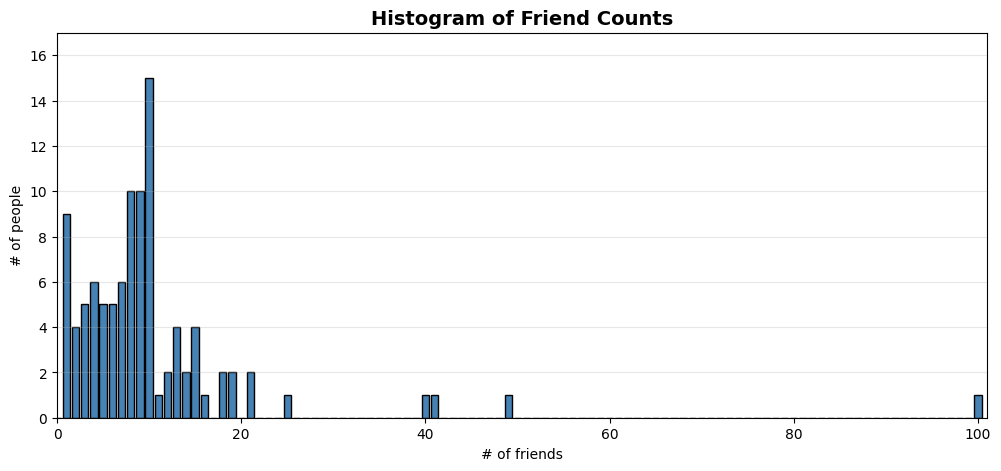

In [4]:
# Sample dataset: friend counts for DataSciencester users
num_friends = [
    100, 49, 41, 40, 25, 21, 21, 19, 19, 18,
    18, 16, 15, 15, 15, 15, 14, 14, 13, 13,
    13, 13, 12, 12, 11, 10, 10, 10, 10, 10,
    10, 10, 10, 10, 10, 10, 10, 10, 10, 10,
    9, 9, 9, 9, 9, 9, 9, 9, 9, 9,
    8, 8, 8, 8, 8, 8, 8, 8, 8, 8,
    7, 7, 7, 7, 7, 7, 6, 6, 6, 6,
    6, 5, 5, 5, 5, 5, 4, 4, 4, 4,
    4, 4, 3, 3, 3, 3, 3, 2, 2, 2,
    2, 1, 1, 1, 1, 1, 1, 1, 1, 1
]

# Basic operations
num_points = len(num_friends)
largest_value = max(num_friends)
smallest_value = min(num_friends)
sorted_values = sorted(num_friends)
second_smallest = sorted_values[1]
second_largest = sorted_values[-2]

print(f"Number of users: {num_points}")
print(f"Largest value: {largest_value}")
print(f"Smallest value: {smallest_value}")
print(f"Second smallest: {second_smallest}")
print(f"Second largest: {second_largest}")

# Visualize with histogram
friend_counts = Counter(num_friends)
xs = range(101)  # Largest value is 100
ys = [friend_counts.get(x, 0) for x in xs]

plt.figure(figsize=(12, 5))
plt.bar(xs, ys, color='steelblue', edgecolor='black')
plt.axis([0, 101, 0, max(ys) + 2])
plt.title("Histogram of Friend Counts", fontsize=14, fontweight='bold')
plt.xlabel("# of friends")
plt.ylabel("# of people")
plt.grid(axis='y', alpha=0.3)
plt.show()


**Reflection:** Looking at the histogram, what do you notice about the distribution? Is it symmetric or skewed?

---

## 2. Central Tendencies

These describe **where the center of the data is**.

### Mean (Average)

The mean is the arithmetic average — sum of all values divided by the count.


In [5]:
def mean(x):
    """Returns the arithmetic mean of x."""
    return sum(x) / len(x)

mean_friends = mean(num_friends)
print(f"Mean number of friends: {mean_friends:.2f}")

Mean number of friends: 10.35


**⚠️ Sensitivity to outliers:**


In [6]:
# Demonstrate how outliers affect the mean
data_normal = [10, 20, 30]
print(f"Mean of [10, 20, 30]: {mean(data_normal)}")  # 20.0

data_with_outlier = [10, 20, 30, 1000]
print(f"Mean of [10, 20, 30, 1000]: {mean(data_with_outlier)}")  # 265.0

print(f"\nThe mean jumped from 20 to 265 — it no longer represents 'typical'!")


Mean of [10, 20, 30]: 20.0
Mean of [10, 20, 30, 1000]: 265.0

The mean jumped from 20 to 265 — it no longer represents 'typical'!


---

### Median (Middle Value)

The median is the middle value after sorting — robust to outliers.


In [7]:
def median(v):
    """Returns the median value of v."""
    n = len(v)
    sorted_v = sorted(v)
    midpoint = n // 2

    if n % 2 == 1:
        # Odd length: return the middle value
        return sorted_v[midpoint]
    else:
        # Even length: average of the two middle values
        lo = midpoint - 1
        hi = midpoint
        return (sorted_v[lo] + sorted_v[hi]) / 2

median_friends = median(num_friends)
print(f"Median number of friends: {median_friends}")

# Compare with mean
print(f"Mean:   {mean_friends:.2f}")
print(f"Median: {median_friends}")

# The median is less affected by outliers
print(f"\nMedian of [10, 20, 30]: {median([10, 20, 30])}")
print(f"Median of [10, 20, 30, 1000]: {median([10, 20, 30, 1000])}")


Median number of friends: 8.5
Mean:   10.35
Median: 8.5

Median of [10, 20, 30]: 20
Median of [10, 20, 30, 1000]: 25.0



**Reflection:** Why is the median more robust to outliers than the mean? When would you use each?

---

### Mode (Most Frequent Value)

The mode is the most common value(s) — useful for categorical data.


In [8]:
def mode(x):
    """Returns a list of the most common value(s) in x."""
    counts = Counter(x)
    max_count = max(counts.values())
    return [x_i for x_i, count in counts.items() if count == max_count]

mode_friends = mode(num_friends)
print(f"Mode(s) of friend counts: {mode_friends}")
print(f"  → {len(mode_friends)} mode(s) found (this data is multimodal)")

# Example with clear mode
test_data = [1, 2, 2, 3, 3, 3, 4, 5]
print(f"\nMode of {test_data}: {mode(test_data)}")


Mode(s) of friend counts: [10]
  → 1 mode(s) found (this data is multimodal)

Mode of [1, 2, 2, 3, 3, 3, 4, 5]: [3]


---

### Quantiles (Percentiles)

Quantiles generalize the median for any percentage.


In [9]:
def quantile(x, p):
    """Returns the p-th percentile value in x."""
    p_index = int(p * len(x))
    return sorted(x)[p_index]

print("Friend count percentiles:")
print(f"  10th percentile: {quantile(num_friends, 0.10)}")
print(f"  25th percentile (Q1): {quantile(num_friends, 0.25)}")
print(f"  50th percentile (Median): {quantile(num_friends, 0.50)}")
print(f"  75th percentile (Q3): {quantile(num_friends, 0.75)}")
print(f"  90th percentile: {quantile(num_friends, 0.90)}")

# Interpretation
print(f"\nInterpretation:")
print(f"  • 10% of users have ≤ {quantile(num_friends, 0.10)} friend(s)")
print(f"  • 25% of users have ≤ {quantile(num_friends, 0.25)} friend(s)")
print(f"  • 75% of users have ≤ {quantile(num_friends, 0.75)} friends")
print(f"  • 90% of users have ≤ {quantile(num_friends, 0.90)} friends")


Friend count percentiles:
  10th percentile: 2
  25th percentile (Q1): 5
  50th percentile (Median): 9
  75th percentile (Q3): 11
  90th percentile: 18

Interpretation:
  • 10% of users have ≤ 2 friend(s)
  • 25% of users have ≤ 5 friend(s)
  • 75% of users have ≤ 11 friends
  • 90% of users have ≤ 18 friends


---

## 3. Dispersion: Measuring Spread

These describe **how spread out the data is**.

### Range



In [10]:
def data_range(x):
    """Returns the difference between max and min values."""
    return max(x) - min(x)

range_friends = data_range(num_friends)
print(f"Range of friend counts: {range_friends}")
print(f"  → From {min(num_friends)} to {max(num_friends)}")

# The range is sensitive to outliers
print(f"\nRange of [10, 20, 30]: {data_range([10, 20, 30])}")           # 20
print(f"Range of [10, 20, 30, 1000]: {data_range([10, 20, 30, 1000])}")  # 990!


Range of friend counts: 99
  → From 1 to 100

Range of [10, 20, 30]: 20
Range of [10, 20, 30, 1000]: 990


---

### Variance & Standard Deviation

Variance measures average squared distance from the mean. Standard deviation brings it back to original units.



In [11]:
# Helper function from Chapter 4
def dot(v, w):
    return sum(v_i * w_i for v_i, w_i in zip(v, w))

def sum_of_squares(v):
    return dot(v, v)

def de_mean(x):
    """Translate x by subtracting its mean (result has mean 0)."""
    x_bar = mean(x)
    return [x_i - x_bar for x_i in x]

def variance(x):
    """Sample variance (uses n-1 denominator)."""
    n = len(x)
    deviations = de_mean(x)
    return sum_of_squares(deviations) / (n - 1)

def standard_deviation(x):
    """Standard deviation = square root of variance."""
    return math.sqrt(variance(x))

var_friends = variance(num_friends)
std_friends = standard_deviation(num_friends)

print(f"Variance of friend counts: {var_friends:.2f} friends²")
print(f"Standard deviation: {std_friends:.2f} friends")

# Interpretation
print(f"\nInterpretation:")
print(f"  • Mean: {mean_friends:.2f} friends")
print(f"  • Typical distance from mean: ±{std_friends:.2f} friends")
print(f"  • Most values fall between {mean_friends - std_friends:.1f} and {mean_friends + std_friends:.1f}")


Variance of friend counts: 143.38 friends²
Standard deviation: 11.97 friends

Interpretation:
  • Mean: 10.35 friends
  • Typical distance from mean: ±11.97 friends
  • Most values fall between -1.6 and 22.3


---

### Interquartile Range (IQR)

The IQR is the range of the middle 50% of data — robust to outliers.


In [12]:
def interquartile_range(x):
    """Returns the difference between 75th and 25th percentiles."""
    return quantile(x, 0.75) - quantile(x, 0.25)

iqr_friends = interquartile_range(num_friends)
print(f"IQR of friend counts: {iqr_friends}")
print(f"  • Q1 (25th): {quantile(num_friends, 0.25)}")
print(f"  • Q3 (75th): {quantile(num_friends, 0.75)}")
print(f"  • IQR = Q3 - Q1 = {iqr_friends}")
print(f"\nThe middle 50% of users have friend counts within a range of {iqr_friends}")

# Outlier detection using IQR
lower_fence = quantile(num_friends, 0.25) - 1.5 * iqr_friends
upper_fence = quantile(num_friends, 0.75) + 1.5 * iqr_friends

outliers = [x for x in num_friends if x < lower_fence or x > upper_fence]
print(f"\nPotential outliers (outside [{lower_fence:.1f}, {upper_fence:.1f}]):")
print(f"  {sorted(set(outliers))}")


IQR of friend counts: 6
  • Q1 (25th): 5
  • Q3 (75th): 11
  • IQR = Q3 - Q1 = 6

The middle 50% of users have friend counts within a range of 6

Potential outliers (outside [-4.0, 20.0]):
  [21, 25, 40, 41, 49, 100]


---

## 4. Correlation: Measuring Relationships

These describe **whether and how variables move together**.


In [13]:
# Sample dataset: daily minutes spent on the site
daily_minutes = [
    1, 68.77, 51.25, 52.08, 38.36, 44.54, 57.13, 51.4, 41.42,
    31.22, 34.76, 54.01, 38.79, 47.59, 49.1, 27.66, 41.03,
    36.73, 48.65, 28.12, 46.62, 35.57, 32.98, 35, 26.07,
    23.77, 39.73, 40.57, 31.65, 31.21, 36.32, 20.45, 21.93
    # Truncated for display — use full list from book
]


### Covariance


In [14]:
def covariance(x, y):
    """Measures how two variables vary together."""
    n = len(x)
    return dot(de_mean(x), de_mean(y)) / (n - 1)

cov_friends_minutes = covariance(num_friends, daily_minutes[:len(num_friends)])
print(f"Covariance (friends, minutes): {cov_friends_minutes:.2f}")
print(f"  → Positive covariance: as friends increase, minutes tend to increase")


Covariance (friends, minutes): -9.04
  → Positive covariance: as friends increase, minutes tend to increase


### Correlation Coefficient (Pearson's r)


Correlation (friends, minutes): -0.126
  → Weak positive correlation


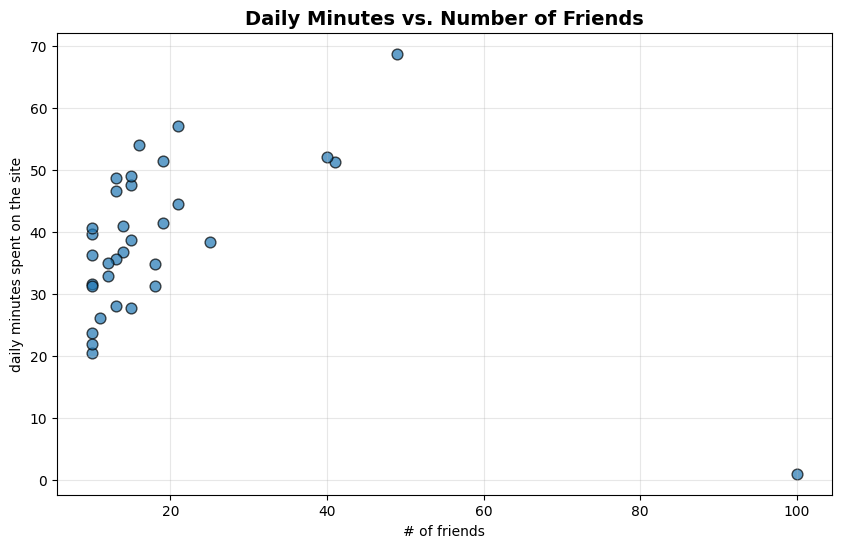

In [15]:
def correlation(x, y):
    """Unitless measure of linear relationship (-1 to +1)."""
    stdev_x = standard_deviation(x)
    stdev_y = standard_deviation(y)
    if stdev_x > 0 and stdev_y > 0:
        return covariance(x, y) / stdev_x / stdev_y
    else:
        return 0  # If no variation, correlation is 0

# Align data lengths
data_length = min(len(num_friends), len(daily_minutes))
corr_friends_minutes = correlation(num_friends[:data_length], daily_minutes[:data_length])

print(f"Correlation (friends, minutes): {corr_friends_minutes:.3f}")
print(f"  → Weak positive correlation")

# Visualize the relationship
plt.figure(figsize=(10, 6))
plt.scatter(num_friends[:data_length], daily_minutes[:data_length],
            alpha=0.7, edgecolors='black', s=60)
plt.title("Daily Minutes vs. Number of Friends", fontsize=14, fontweight='bold')
plt.xlabel("# of friends")
plt.ylabel("daily minutes spent on the site")
plt.grid(True, alpha=0.3)
plt.show()


### ⚠️ Outliers Can Distort Correlation


Correlation WITH outlier: -0.126
Correlation WITHOUT outlier: 0.673
  → Removing one outlier nearly doubled the correlation!


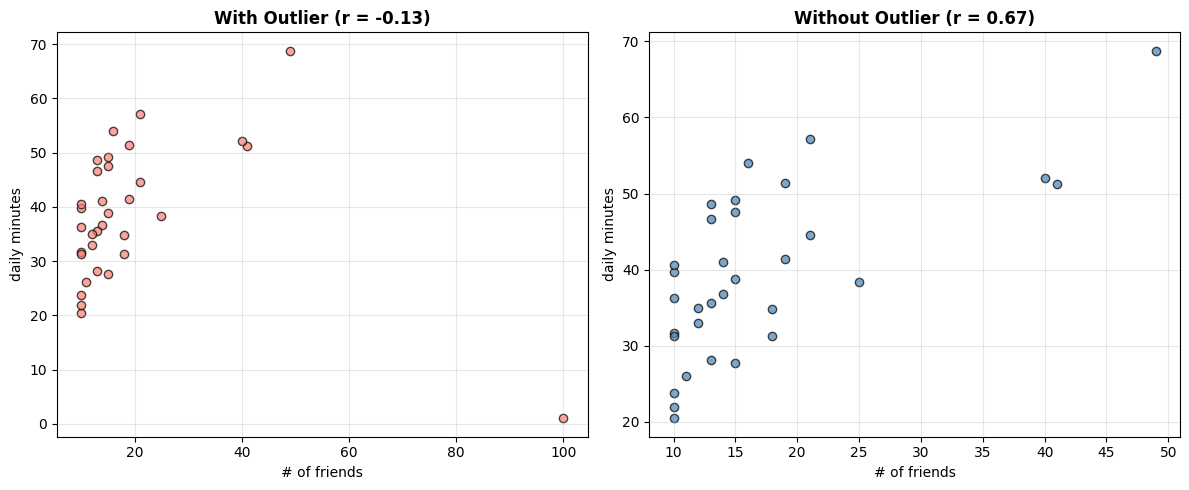

In [16]:
# Find and remove the outlier
outlier_index = num_friends.index(100)  # User with 100 friends

num_friends_clean = [x for i, x in enumerate(num_friends[:data_length]) if i != outlier_index]
daily_minutes_clean = [x for i, x in enumerate(daily_minutes[:data_length]) if i != outlier_index]

corr_clean = correlation(num_friends_clean, daily_minutes_clean)
print(f"Correlation WITH outlier: {corr_friends_minutes:.3f}")
print(f"Correlation WITHOUT outlier: {corr_clean:.3f}")
print(f"  → Removing one outlier nearly doubled the correlation!")

# Visualize without outlier
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(num_friends[:data_length], daily_minutes[:data_length],
            alpha=0.7, edgecolors='black', color='salmon')
plt.title(f"With Outlier (r = {corr_friends_minutes:.2f})", fontweight='bold')
plt.xlabel("# of friends")
plt.ylabel("daily minutes")
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.scatter(num_friends_clean, daily_minutes_clean,
            alpha=0.7, edgecolors='black', color='steelblue')
plt.title(f"Without Outlier (r = {corr_clean:.2f})", fontweight='bold')
plt.xlabel("# of friends")
plt.ylabel("daily minutes")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


---

## 5. Simpson's Paradox

A correlation can reverse when you account for a confounding variable.


In [17]:
# Constructed data illustrating Simpson's Paradox
# Comparing friend counts by region and PhD status

data = [
    # West Coast, No PhD (higher friends on average)
    ("West", "No PhD", 10.9), ("West", "No PhD", 10.9), ("West", "No PhD", 10.9),
    # West Coast, PhD (lower friends)
    ("West", "PhD", 3.1), ("West", "PhD", 3.1), ("West", "PhD", 3.1),
    # East Coast, No PhD (even higher friends)
    ("East", "No PhD", 13.4), ("East", "No PhD", 13.4), ("East", "No PhD", 13.4),
    # East Coast, PhD (slightly higher than West PhD)
    ("East", "PhD", 3.2), ("East", "PhD", 3.2), ("East", "PhD", 3.2),
]

# Overall averages by coast
west_friends = [d[2] for d in data if d[0] == "West"]
east_friends = [d[2] for d in data if d[0] == "East"]

print("=" * 50)
print("SIMPSON'S PARADOX DEMONSTRATION")
print("=" * 50)

print(f"\nOverall Averages:")
print(f"  West Coast: {mean(west_friends):.2f} friends")
print(f"  East Coast: {mean(east_friends):.2f} friends")
print(f"  → West Coast appears MORE social!")

# Averages within PhD status
west_phd = [d[2] for d in data if d[0] == "West" and d[1] == "PhD"]
east_phd = [d[2] for d in data if d[0] == "East" and d[1] == "PhD"]
west_no_phd = [d[2] for d in data if d[0] == "West" and d[1] == "No PhD"]
east_no_phd = [d[2] for d in data if d[0] == "East" and d[1] == "No PhD"]

print(f"\nBy PhD Status:")
print(f"  West Coast PhD:    {mean(west_phd):.2f}")
print(f"  East Coast PhD:    {mean(east_phd):.2f}  ← Higher!")
print(f"  West Coast No PhD: {mean(west_no_phd):.2f}")
print(f"  East Coast No PhD: {mean(east_no_phd):.2f}  ← Higher!")

print(f"\n🔍 The Paradox:")
print(f"  Overall: West > East")
print(f"  Within each group: East > West")
print(f"  Cause: West has more PhDs (who have fewer friends)")
print(f"         This pulls down the overall West average")


SIMPSON'S PARADOX DEMONSTRATION

Overall Averages:
  West Coast: 7.00 friends
  East Coast: 8.30 friends
  → West Coast appears MORE social!

By PhD Status:
  West Coast PhD:    3.10
  East Coast PhD:    3.20  ← Higher!
  West Coast No PhD: 10.90
  East Coast No PhD: 13.40  ← Higher!

🔍 The Paradox:
  Overall: West > East
  Within each group: East > West
  Cause: West has more PhDs (who have fewer friends)
         This pulls down the overall West average


---
## 6. Summary Statistics Function

Putting it all together into a useful summary function:


In [18]:
def describe(data, name="Data"):
    """Prints comprehensive summary statistics for a dataset."""
    print(f"Summary Statistics: {name}")
    print("-" * 40)
    print(f"  Count:        {len(data)}")
    print(f"  Min:          {min(data)}")
    print(f"  Max:          {max(data)}")
    print(f"  Range:        {data_range(data)}")
    print(f"  Mean:         {mean(data):.2f}")
    print(f"  Median:       {median(data)}")
    print(f"  Mode:         {mode(data)}")
    print(f"  Variance:     {variance(data):.2f}")
    print(f"  Std Dev:      {standard_deviation(data):.2f}")
    print(f"  Q1 (25th):    {quantile(data, 0.25)}")
    print(f"  Q3 (75th):    {quantile(data, 0.75)}")
    print(f"  IQR:          {interquartile_range(data)}")
    print("-" * 40)

# Test
describe(num_friends, "Friend Counts")


Summary Statistics: Friend Counts
----------------------------------------
  Count:        100
  Min:          1
  Max:          100
  Range:        99
  Mean:         10.35
  Median:       8.5
  Mode:         [10]
  Variance:     143.38
  Std Dev:      11.97
  Q1 (25th):    5
  Q3 (75th):    11
  IQR:          6
----------------------------------------


---

## Real-World ML Connection

Statistics is used heavily throughout the ML lifecycle:

### Exploratory Data Analysis (EDA)
- Understanding distributions, outliers, and spread
- Identifying data quality issues early

### Feature Engineering
- Finding anomalies that need handling
- Identifying scaling needs (standard deviation for standardization)
- Detecting relationships between features (correlation)

### Model Evaluation
- Understanding performance metrics
- Comparing models with statistical significance
- Analyzing residual distributions

### Production Monitoring
Watching for:
- **Mean drift** — is the average changing over time?
- **Variance drift** — is the spread changing?
- **Distribution shifts** — is the entire data distribution changing?

### A/B Testing
- Statistical reasoning helps compare system variants
- Understanding sample size and significance

---

## 🎯 Chapter 5 Summary

| Concept | Function | Why It Matters |
|---------|----------|----------------|
| Mean | `mean(x)` | Average value; sensitive to outliers |
| Median | `median(v)` | Middle value; robust to outliers |
| Mode | `mode(x)` | Most frequent value(s); useful for categorical data |
| Quantile | `quantile(x, p)` | Where values lie in the distribution |
| Range | `data_range(x)` | Simple spread measure; sensitive to outliers |
| Variance | `variance(x)` | Average squared deviation from mean |
| Standard Deviation | `standard_deviation(x)` | Spread in original units |
| IQR | `interquartile_range(x)` | Robust spread measure (middle 50%) |
| Covariance | `covariance(x, y)` | How two variables vary together |
| Correlation | `correlation(x, y)` | Unitless linear relationship (-1 to +1) |

### Key Lessons

1. **No single metric tells the whole story** — use mean AND median, variance AND IQR
2. **Outliers distort everything** — always visualize and investigate before computing statistics
3. **Correlation ≠ Causation** — correlation suggests hypotheses; experiments test causation
4. **Simpson's Paradox is real** — always control for confounding variables
5. **Visualize before computing** — graphs often reveal what summary statistics hide

---

## 📝 Reflection

### Key Takeaways
- Mean summarizes data but is sensitive to outliers
- Median handles outliers better for skewed distributions
- Variance measures spread; standard deviation makes it interpretable
- Quantiles help understand where values rank in the distribution
- Correlation finds relationships but doesn't imply causation
- Statistics powers ML understanding at every stage

### Connection to Machine Learning
Statistics is foundational for:
- **Feature engineering** — scaling, outlier detection, relationship discovery
- **Evaluation** — performance metrics, statistical significance
- **Experimentation** — A/B testing, hypothesis testing
- **Monitoring** — drift detection, anomaly detection
- **Debugging** — understanding why models behave as they do

---
